In [ ]:
import pandas as pd

df = pd.read_csv('/content/gait_dataset.csv')
df.head()

,AccX,AccY,AccZ,AngleX,Steps,Activity
0,-0.17,0.01,1.02,10.97,0,Fall
1,-0.16,0.15,0.89,4.34,0,Fall
2,-0.91,0.67,1.11,9.11,1,Fall
3,-0.13,-0.06,1.02,18.10,1,Fall
4,-0.03,0.06,0.96,15.62,1,Fall


In [ ]:
print(df.shape)
print(df.columns)
print(df['Activity'].value_counts())
print(df.isnull().sum())
print(df.head())
print(dict(zip(le.classes_, le.transform(le.classes_))))

(10720, 6)
Index(['AccX', 'AccY', 'AccZ', 'AngleX', 'Steps', 'Activity'], dtype='object')
Activity
4    2404
0    2270
2    2165
1    1993
3    1888
Name: count, dtype: int64
AccX        0
AccY        0
AccZ        0
AngleX      0
Steps       0
Activity    0
dtype: int64
   AccX  AccY  AccZ  AngleX  Steps  Activity
0 -0.17  0.01  1.02   10.97      0         0
1 -0.16  0.15  0.89    4.34      0         0
2 -0.91  0.67  1.11    9.11      1         0
3 -0.13 -0.06  1.02   18.10      1         0
4 -0.03  0.06  0.96   15.62      1         0
{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}


In [ ]:
X = df.drop('Activity', axis=1)
y = df['Activity']

print(X.shape)
print(y.shape)

(10720, 5)
(10720,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8576, 5)
(2144, 5)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train[:5])

[[ 1.23243673  3.54385183 -1.63989469  0.44792873  0.90749177]
 [-0.18389822  0.14191877 -0.30201431  0.13541351 -0.83120971]
 [-0.13963775 -0.26717444 -0.01385545  0.52006062  0.32792461]
 [ 0.48000879 -0.09492467 -1.22823919 -1.80860009  1.02681443]
 [-0.07324705  0.07732511  0.06847565  0.56178562 -0.84825581]]


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.6194029850746269


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.8479477611940298


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.8768656716417911


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", acc_knn)

KNN Accuracy: 0.8591417910447762


In [ ]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.7985074626865671


In [ ]:
!pip install -q xgboost

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", acc_xgb)

XGBoost Accuracy: 0.8703358208955224


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": (lr, y_pred_lr),
    "Decision Tree": (dt, y_pred_dt),
    "Random Forest": (rf, y_pred_rf),
    "KNN": (knn, y_pred_knn),
    "SVM": (svm, y_pred_svm),
    "XGBoost": (xgb, y_pred_xgb)
}

results = []

for name, (_, y_pred) in models.items():

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    ])

results_df = pd.DataFrame(
    results,
    columns=['Model','Accuracy','Precision','Recall','F1 Score']
)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
2        Random Forest  0.876866   0.877029  0.876866  0.876848
5              XGBoost  0.870336   0.870028  0.870336  0.869584
3                  KNN  0.859142   0.858099  0.859142  0.857606
1        Decision Tree  0.847948   0.848925  0.847948  0.848365
4                  SVM  0.798507   0.797047  0.798507  0.796306
0  Logistic Regression  0.619403   0.619221  0.619403  0.609202


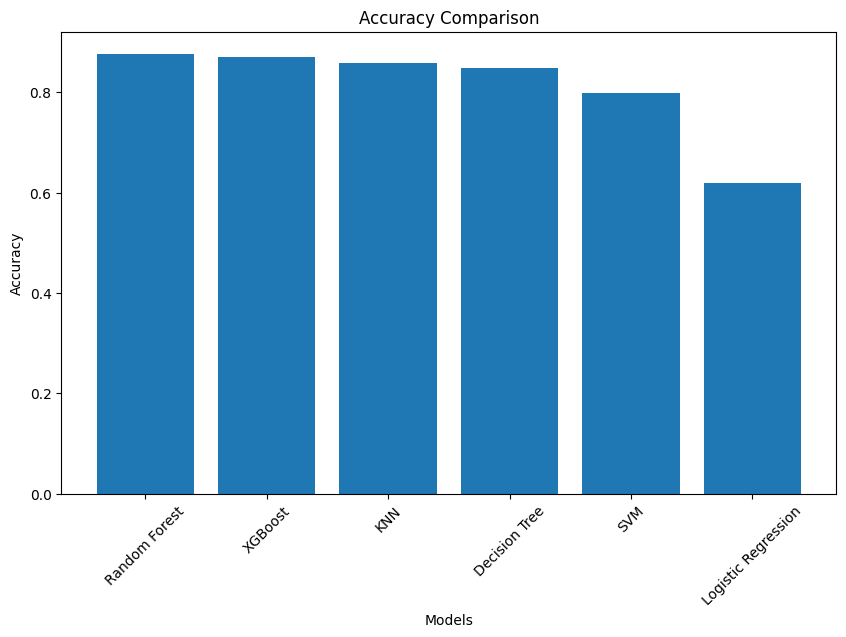

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(results_df['Model'],
        results_df['Accuracy'])

plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()

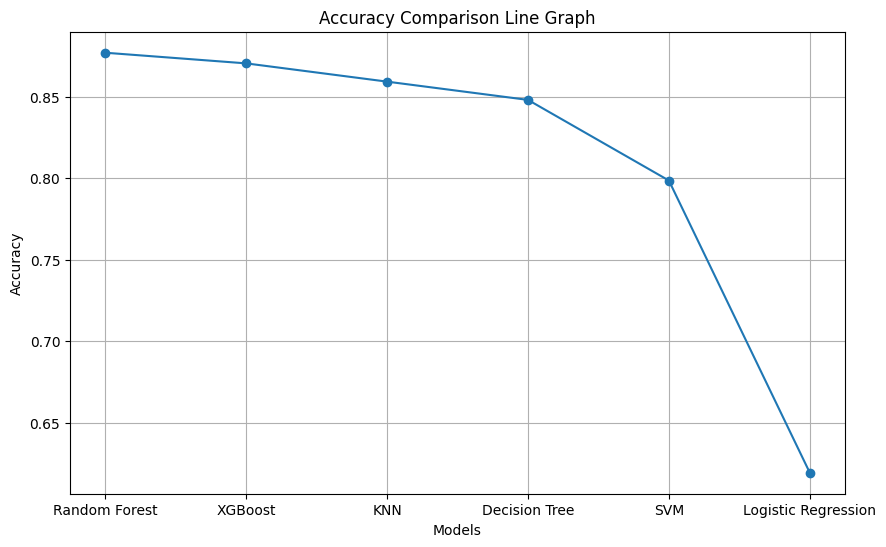

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(results_df['Model'],
         results_df['Accuracy'],
         marker='o')

plt.title("Accuracy Comparison Line Graph")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

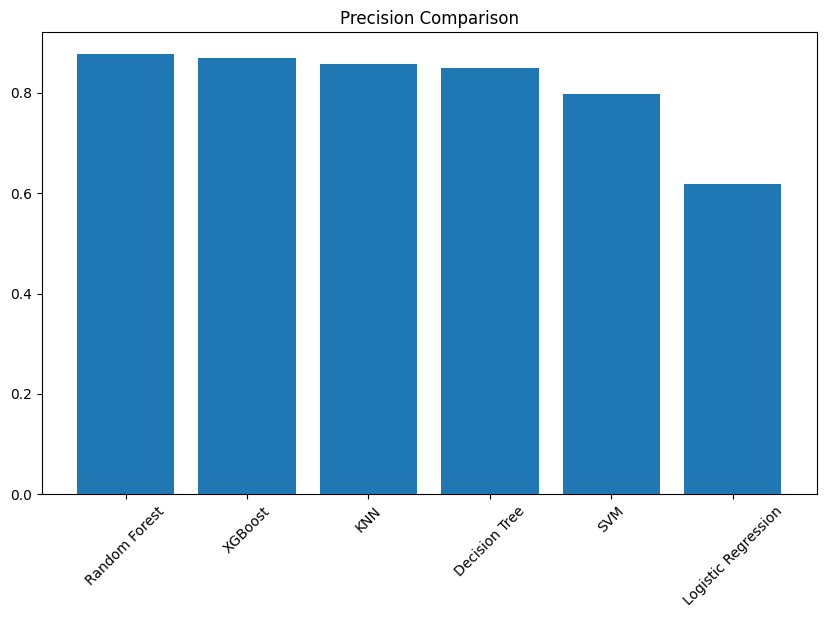

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(results_df['Model'],
        results_df['Precision'])

plt.title("Precision Comparison")
plt.xticks(rotation=45)

plt.show()

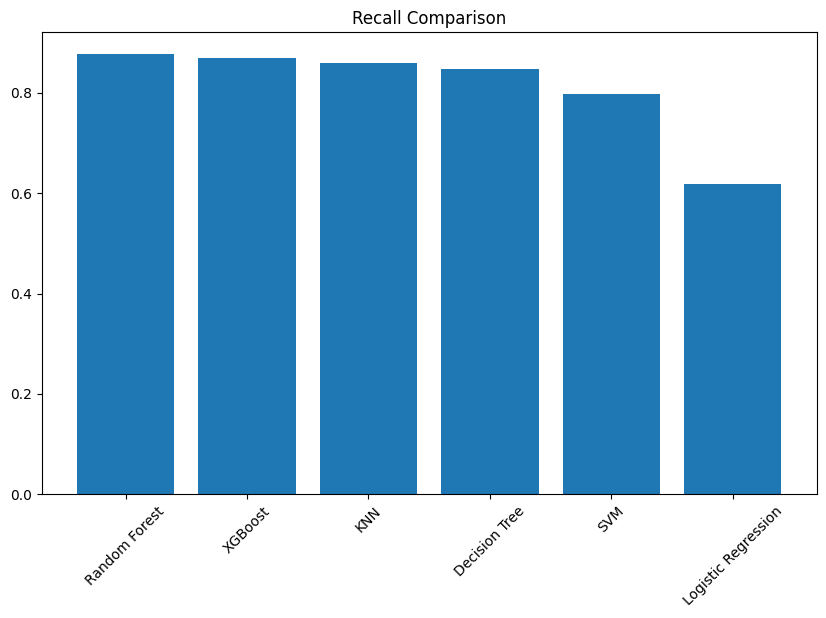

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(results_df['Model'],
        results_df['Recall'])

plt.title("Recall Comparison")
plt.xticks(rotation=45)

plt.show()

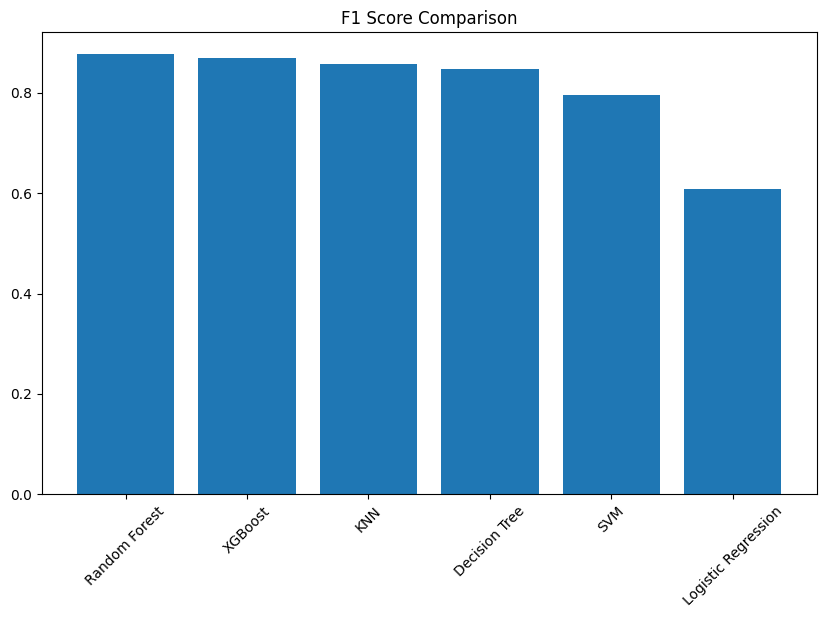

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(results_df['Model'],
        results_df['F1 Score'])

plt.title("F1 Score Comparison")
plt.xticks(rotation=45)

plt.show()

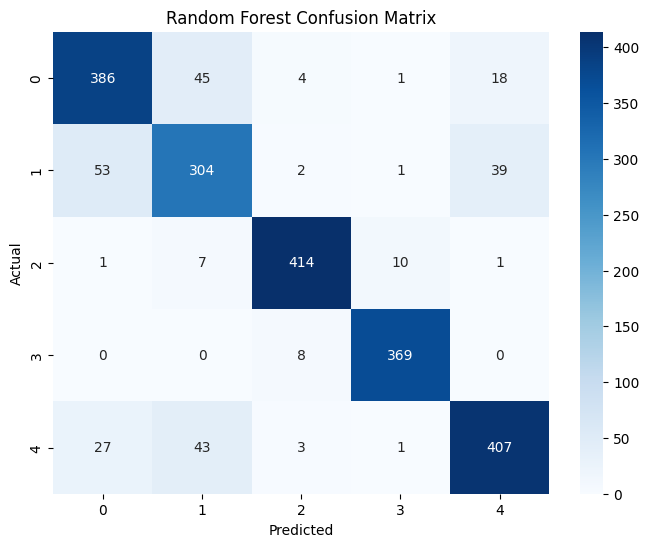

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

  Feature  Importance
4   Steps    0.324885
2    AccZ    0.216576
0    AccX    0.166703
3  AngleX    0.147848
1    AccY    0.143988


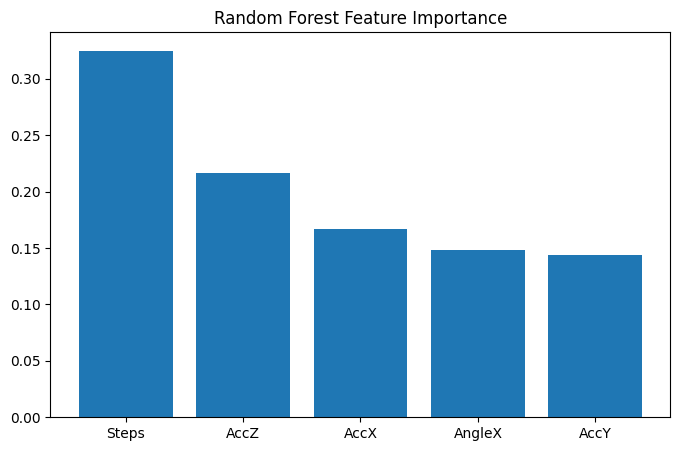

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(feature_importance['Feature'],
        feature_importance['Importance'])

plt.title("Random Forest Feature Importance")

plt.show()

   AccX  AccY  AccZ  AngleX  Steps Activity
0 -0.17  0.01  1.02   10.97      0     Fall
1 -0.16  0.15  0.89    4.34      0     Fall
2 -0.91  0.67  1.11    9.11      1     Fall
3 -0.13 -0.06  1.02   18.10      1     Fall
4 -0.03  0.06  0.96   15.62      1     Fall

Training Logistic Regression


<Figure size 1000x800 with 0 Axes>

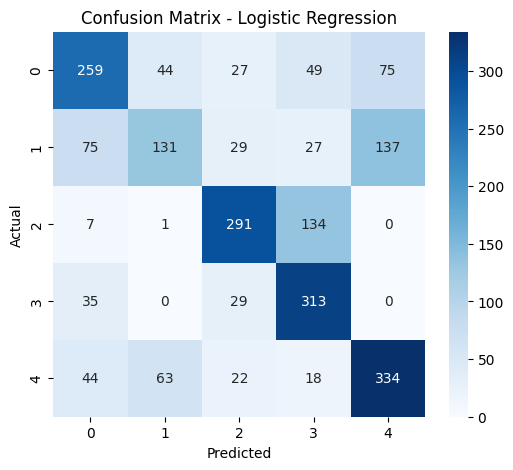


Training KNN


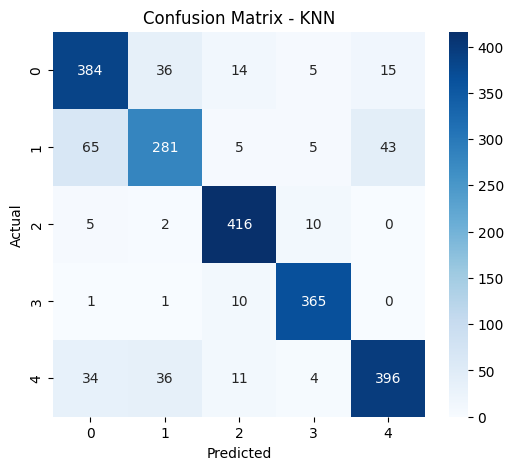


Training SVM


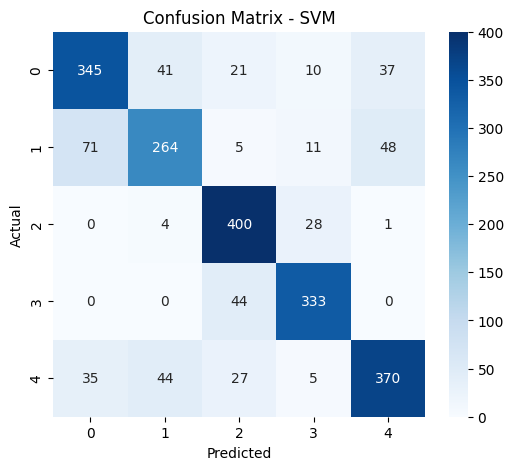


Training Random Forest


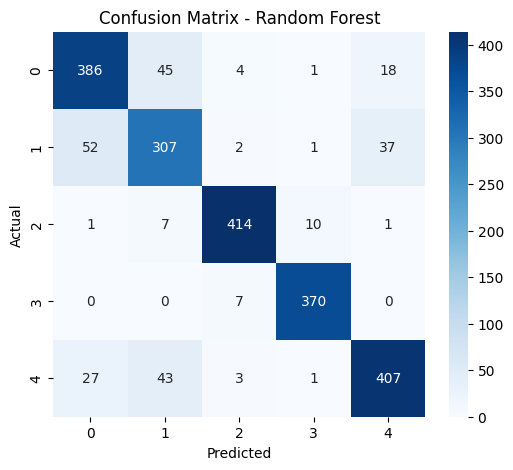


Training XGBoost


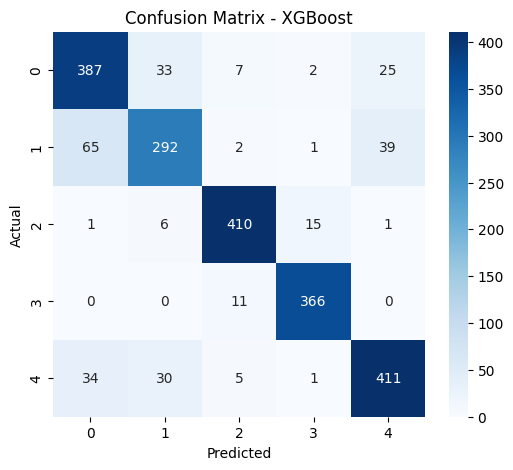


Training LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000784 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1211
[LightGBM] [Info] Number of data points in the train set: 8576, number of used features: 5
[LightGBM] [Info] Start training from score -1.552331
[LightGBM] [Info] Start training from score -1.682721
[LightGBM] [Info] Start training from score -1.599691
[LightGBM] [Info] Start training from score -1.736196
[LightGBM] [Info] Start training from score -1.495081


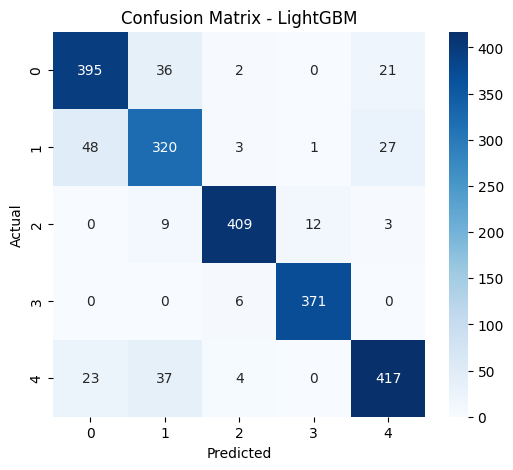


Comparison Table

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.619403   0.619221  0.619403  0.609202
1                  KNN  0.859142   0.858099  0.859142  0.857606
2                  SVM  0.798507   0.797047  0.798507  0.796306
3        Random Forest  0.878731   0.879050  0.878731  0.878775
4              XGBoost  0.870336   0.870028  0.870336  0.869584
5             LightGBM  0.891791   0.892230  0.891791  0.891905


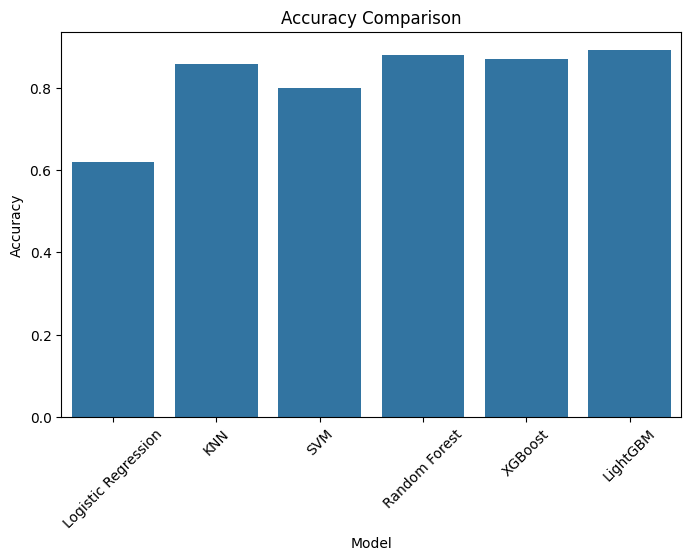

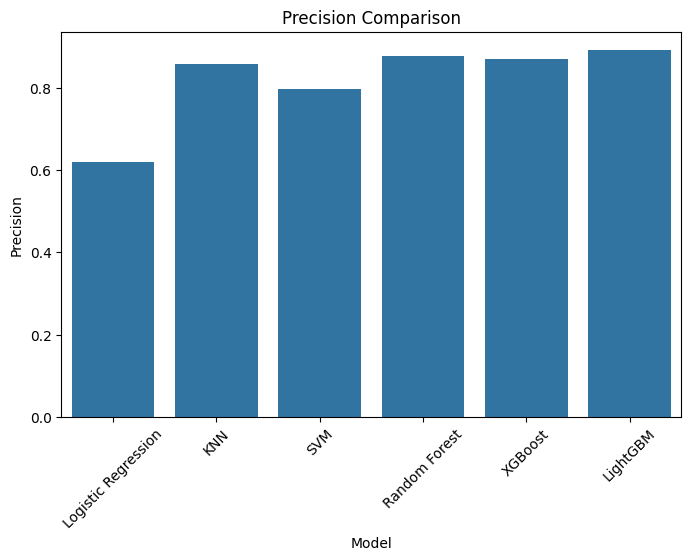

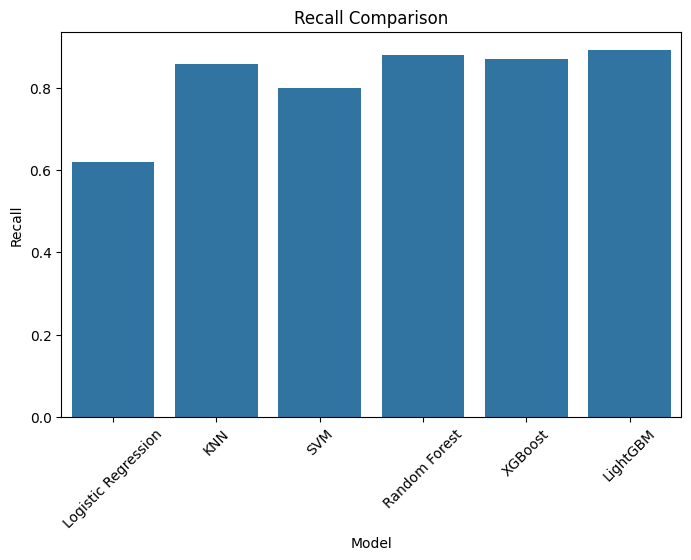

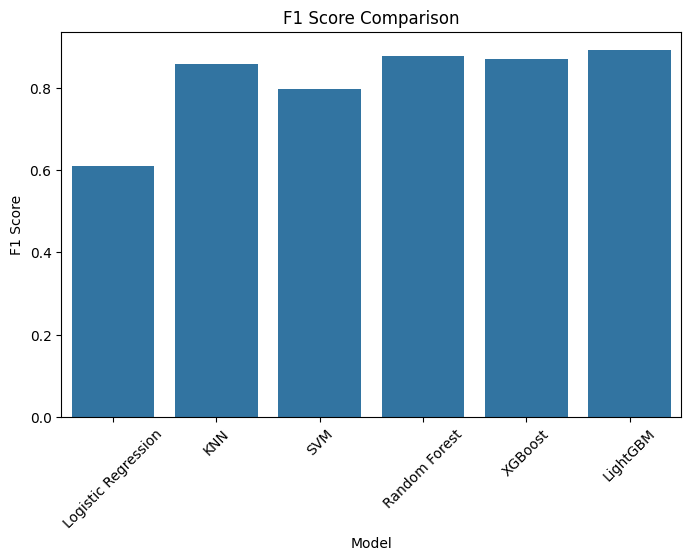

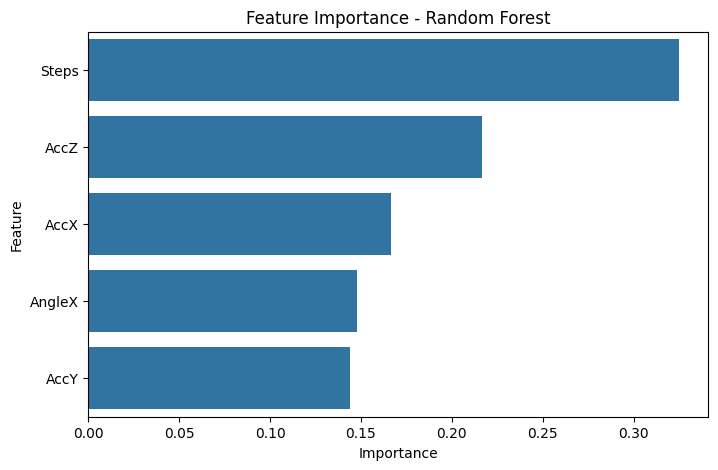

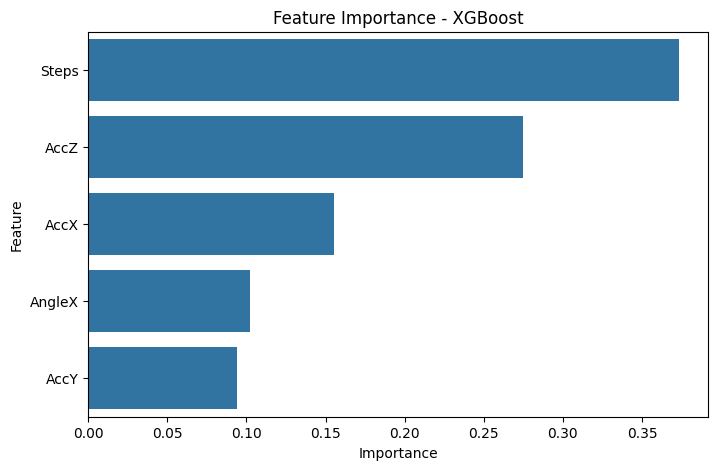

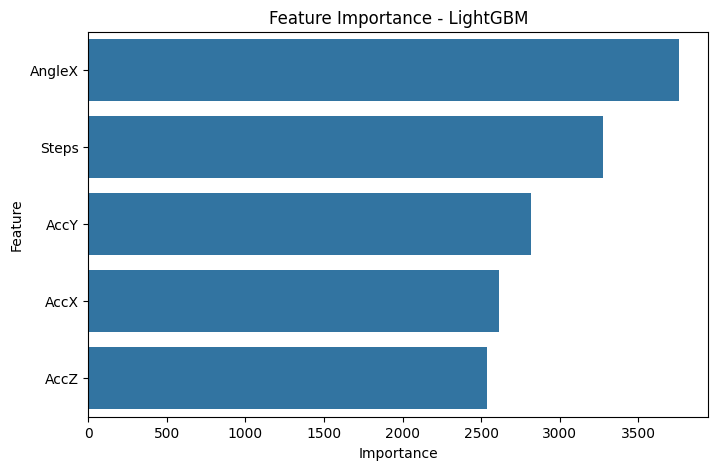


Completed Successfully


In [ ]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("gait_dataset.csv")

print(df.head())

# ==========================================
# ENCODE TARGET COLUMN
# ==========================================

label_encoder = LabelEncoder()
df['Activity'] = label_encoder.fit_transform(df['Activity'])

# ==========================================
# FEATURES AND TARGET
# ==========================================

X = df.drop('Activity', axis=1)
y = df['Activity']

feature_names = X.columns

# ==========================================
# SPLIT DATA
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# STANDARDIZATION
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# MODELS
# ==========================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        probability=True
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        eval_metric='logloss',
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=100,
        random_state=42
    )
}

# ==========================================
# TRAIN & EVALUATE
# ==========================================

results = []

plt.figure(figsize=(10,8))

for name, model in models.items():

    print(f"\nTraining {name}")

    # Use scaled data for LR, KNN, SVM
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        y_prob = model.predict_proba(X_test_scaled)

    else:
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    rec = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    results.append([
        name,
        acc,
        prec,
        rec,
        f1
    ])

    # ROC Curve (Binary Classification)
    if len(np.unique(y)) == 2:

        fpr, tpr, _ = roc_curve(
            y_test,
            y_prob[:,1]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f'{name} (AUC={roc_auc:.3f})'
        )

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# ==========================================
# COMPARISON TABLE
# ==========================================

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

print("\nComparison Table\n")
print(results_df)

# ==========================================
# SAVE TABLE
# ==========================================

results_df.to_csv(
    "Model_Comparison.csv",
    index=False
)

# ==========================================
# ACCURACY GRAPH
# ==========================================

plt.figure(figsize=(8,5))
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df
)
plt.xticks(rotation=45)
plt.title("Accuracy Comparison")
plt.show()

# ==========================================
# PRECISION GRAPH
# ==========================================

plt.figure(figsize=(8,5))
sns.barplot(
    x='Model',
    y='Precision',
    data=results_df
)
plt.xticks(rotation=45)
plt.title("Precision Comparison")
plt.show()

# ==========================================
# RECALL GRAPH
# ==========================================

plt.figure(figsize=(8,5))
sns.barplot(
    x='Model',
    y='Recall',
    data=results_df
)
plt.xticks(rotation=45)
plt.title("Recall Comparison")
plt.show()

# ==========================================
# F1 SCORE GRAPH
# ==========================================

plt.figure(figsize=(8,5))
sns.barplot(
    x='Model',
    y='F1 Score',
    data=results_df
)
plt.xticks(rotation=45)
plt.title("F1 Score Comparison")
plt.show()

# ==========================================
# ROC CURVE
# ==========================================

if len(np.unique(y)) == 2:

    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.show()

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance_models = {
    "Random Forest":
        models["Random Forest"],

    "XGBoost":
        models["XGBoost"],

    "LightGBM":
        models["LightGBM"]
}

for name, model in importance_models.items():

    importance = model.feature_importances_

    feature_imp = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })

    feature_imp = feature_imp.sort_values(
        by='Importance',
        ascending=False
    )

    plt.figure(figsize=(8,5))

    sns.barplot(
        x='Importance',
        y='Feature',
        data=feature_imp
    )

    plt.title(f'Feature Importance - {name}')

    plt.show()

print("\nCompleted Successfully")

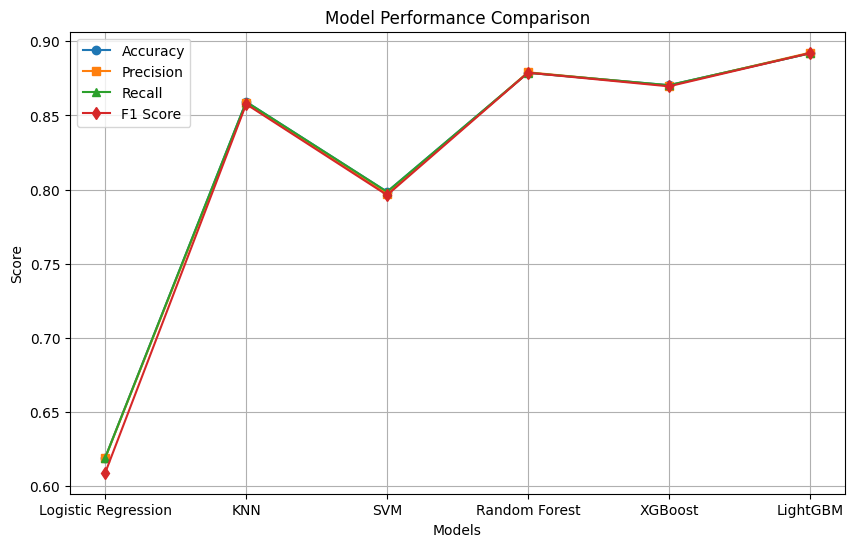

In [ ]:
# Line Graph Comparison

plt.figure(figsize=(10,6))

plt.plot(results_df['Model'],
         results_df['Accuracy'],
         marker='o',
         label='Accuracy')

plt.plot(results_df['Model'],
         results_df['Precision'],
         marker='s',
         label='Precision')

plt.plot(results_df['Model'],
         results_df['Recall'],
         marker='^',
         label='Recall')

plt.plot(results_df['Model'],
         results_df['F1 Score'],
         marker='d',
         label='F1 Score')

plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.show()

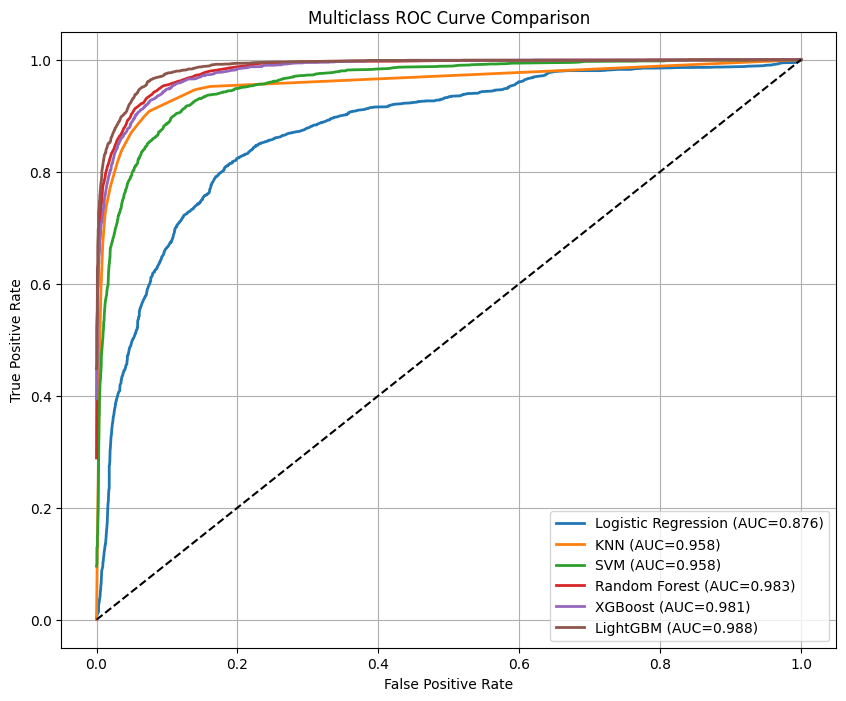

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Binarize labels
y_test_bin = label_binarize(y_test, classes=np.unique(y))

plt.figure(figsize=(10,8))

for name, model in models.items():

    if name in ["Logistic Regression","KNN","SVM"]:
        y_score = model.predict_proba(X_test_scaled)
    else:
        y_score = model.predict_proba(X_test)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(y_test_bin.shape[1]):
        fpr[i], tpr[i], _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc[i] = auc(fpr[i], tpr[i])

    all_fpr = np.unique(
        np.concatenate(
            [fpr[i] for i in range(y_test_bin.shape[1])]
        )
    )

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(y_test_bin.shape[1]):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= y_test_bin.shape[1]

    macro_auc = auc(all_fpr, mean_tpr)

    plt.plot(
        all_fpr,
        mean_tpr,
        lw=2,
        label=f'{name} (AUC={macro_auc:.3f})'
    )

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

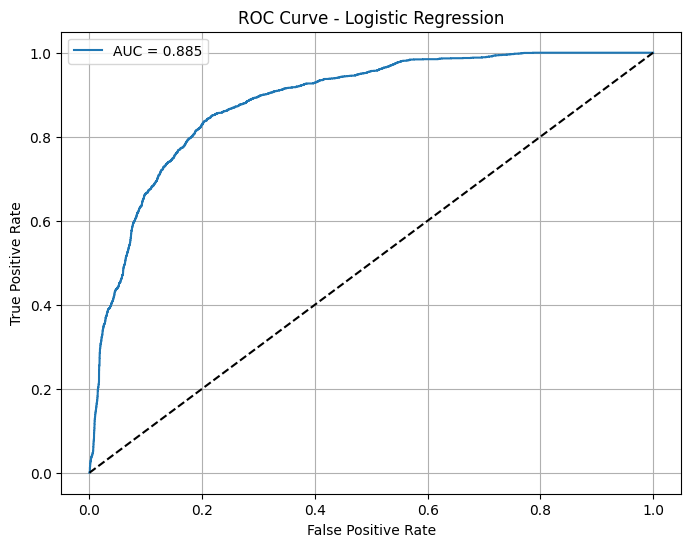

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

y_test_bin = label_binarize(y_test, classes=np.unique(y))

y_score = models["Logistic Regression"].predict_proba(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

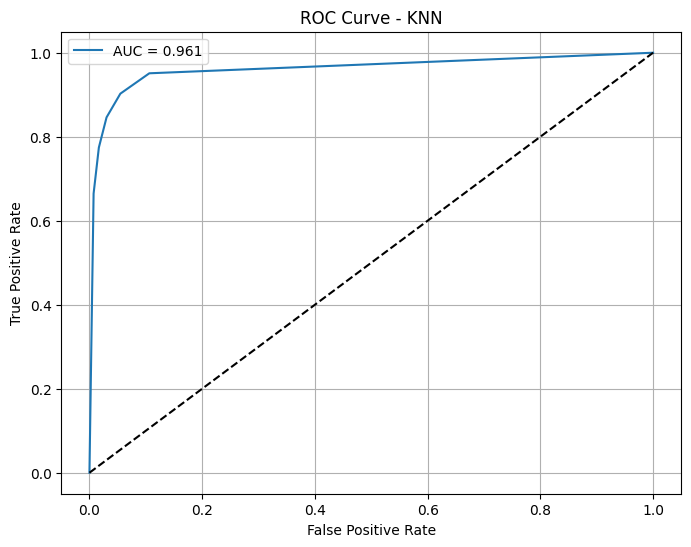

In [ ]:
y_score = models["KNN"].predict_proba(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend()
plt.grid(True)
plt.show()

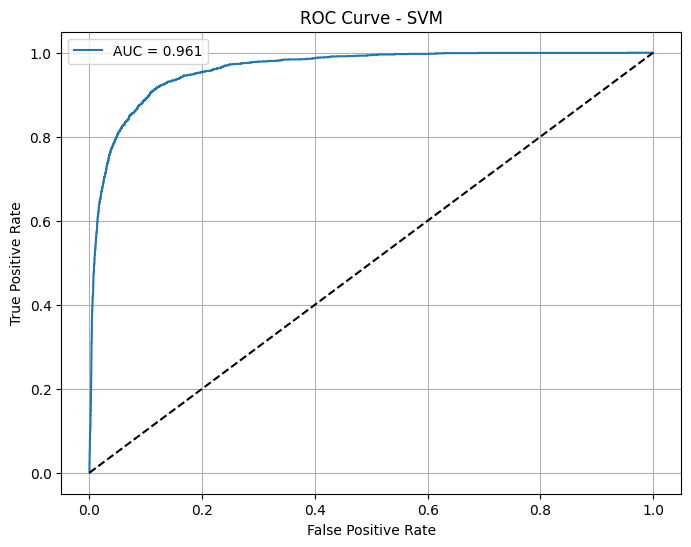

In [ ]:
y_score = models["SVM"].predict_proba(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend()
plt.grid(True)
plt.show()

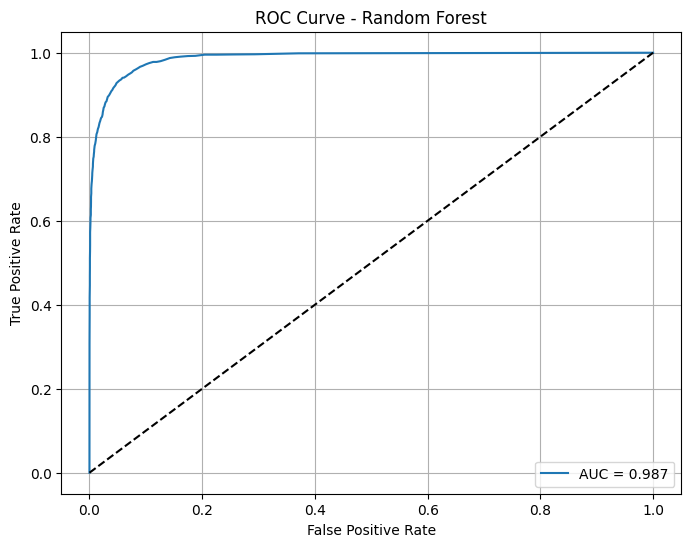

In [ ]:
y_score = models["Random Forest"].predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid(True)
plt.show()

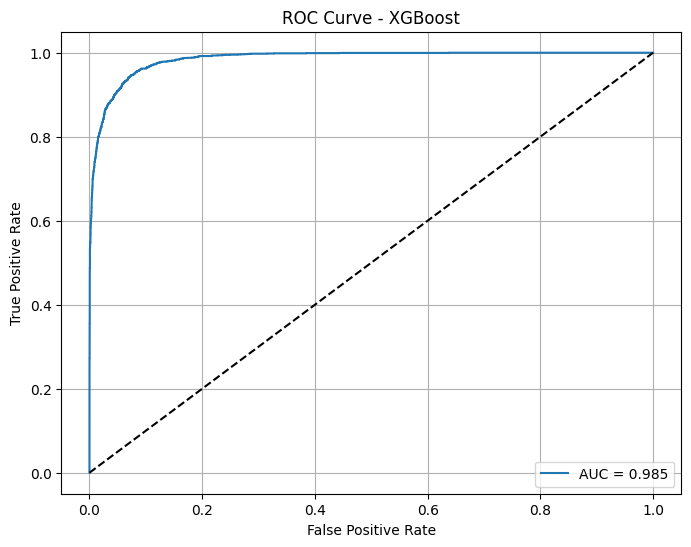

In [ ]:
y_score = models["XGBoost"].predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

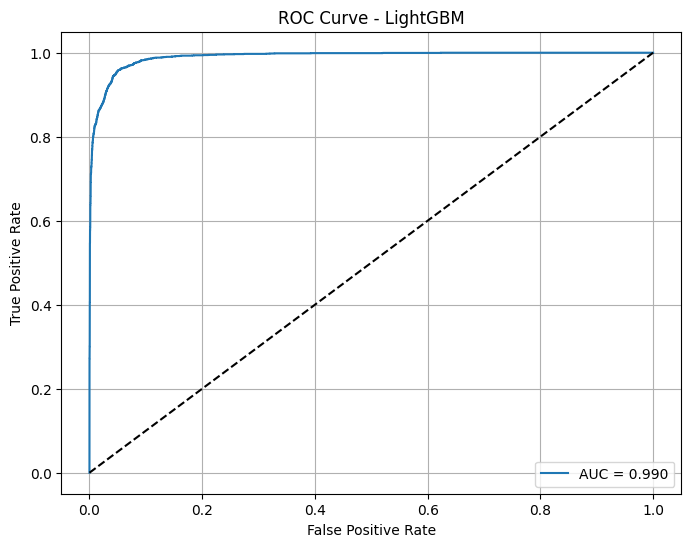

In [ ]:
y_score = models["LightGBM"].predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM')
plt.legend()
plt.grid(True)
plt.show()

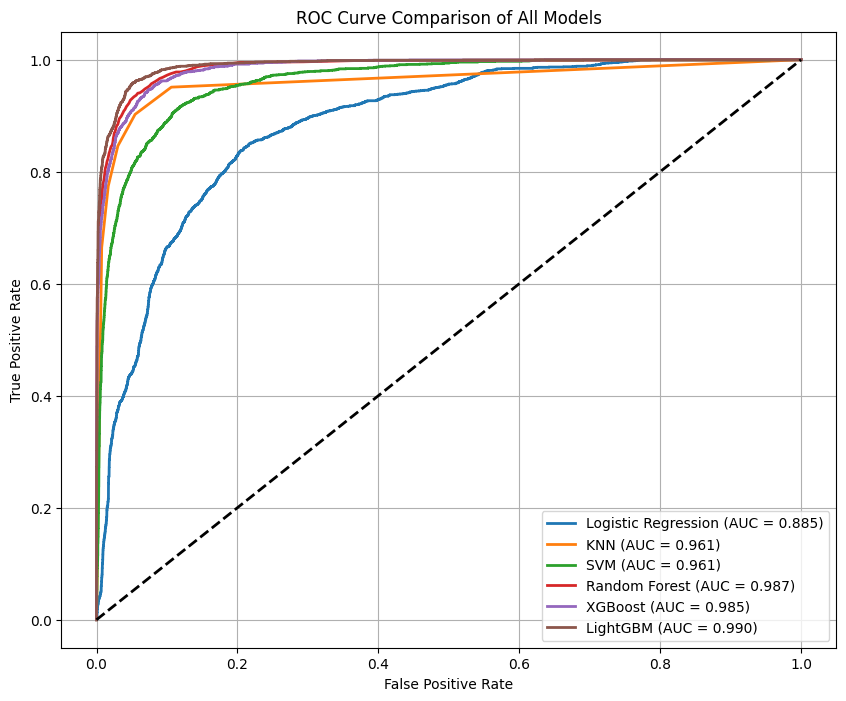

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Convert multiclass labels to binary format
y_test_bin = label_binarize(y_test, classes=np.unique(y))

plt.figure(figsize=(10,8))

for name, model in models.items():

    # Get probabilities
    if name in ["Logistic Regression", "KNN", "SVM"]:
        y_score = model.predict_proba(X_test_scaled)
    else:
        y_score = model.predict_proba(X_test)

    # Micro-average ROC
    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        y_score.ravel()
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{name} (AUC = {roc_auc:.3f})'
    )

# Random classifier line
plt.plot([0,1], [0,1], 'k--', lw=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of All Models')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

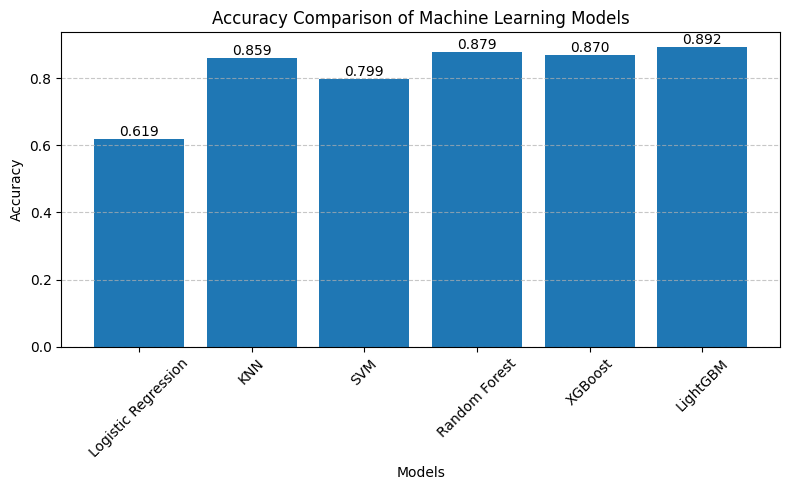

In [ ]:
plt.figure(figsize=(8,5))

accuracy_values = results_df['Accuracy']

bars = plt.bar(
    results_df['Model'],
    accuracy_values
)

plt.title('Accuracy Comparison of Machine Learning Models')
plt.xlabel('Models')
plt.ylabel('Accuracy')

# Display values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

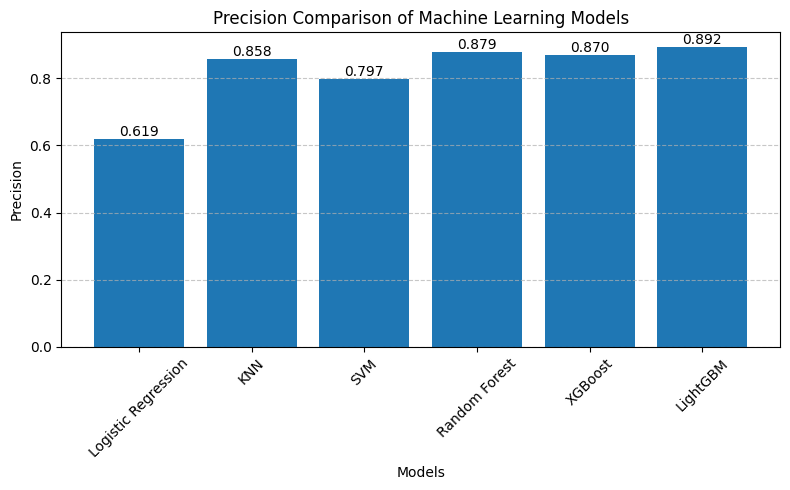

In [ ]:
plt.figure(figsize=(8,5))

precision_values = results_df['Precision']

bars = plt.bar(
    results_df['Model'],
    precision_values
)

plt.title('Precision Comparison of Machine Learning Models')
plt.xlabel('Models')
plt.ylabel('Precision')

# Display values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

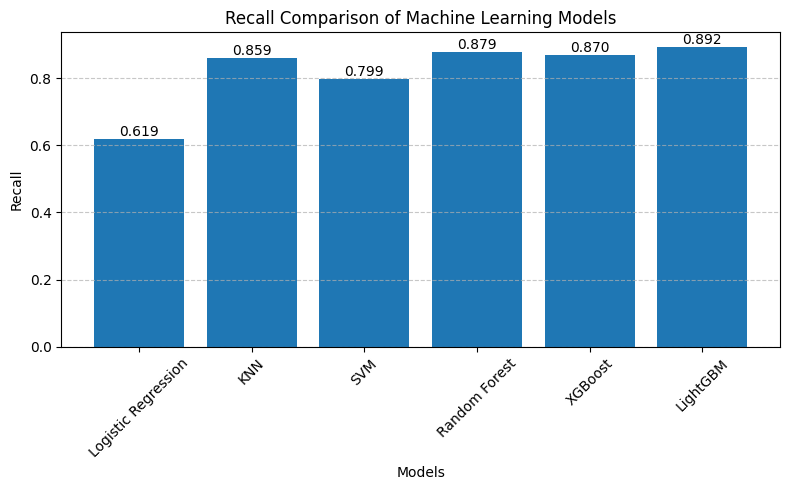

In [ ]:
plt.figure(figsize=(8,5))

recall_values = results_df['Recall']

bars = plt.bar(
    results_df['Model'],
    recall_values
)

plt.title('Recall Comparison of Machine Learning Models')
plt.xlabel('Models')
plt.ylabel('Recall')

# Display values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

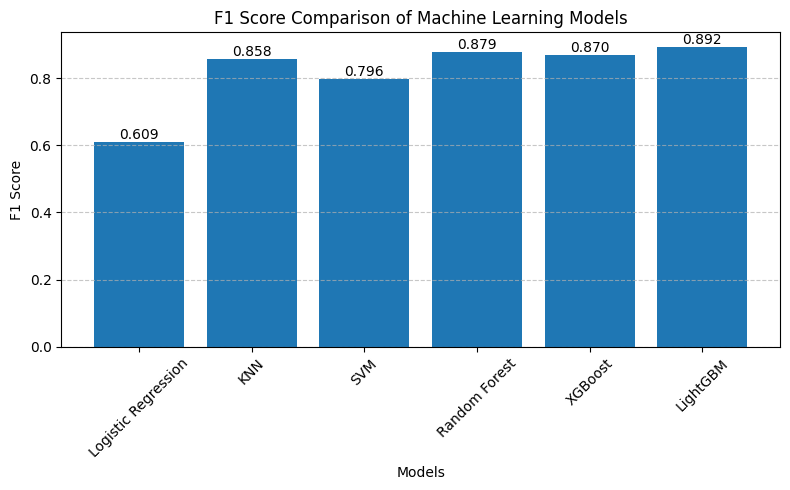

In [ ]:
plt.figure(figsize=(8,5))

f1_values = results_df['F1 Score']

bars = plt.bar(
    results_df['Model'],
    f1_values
)

plt.title('F1 Score Comparison of Machine Learning Models')
plt.xlabel('Models')
plt.ylabel('F1 Score')

# Display values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

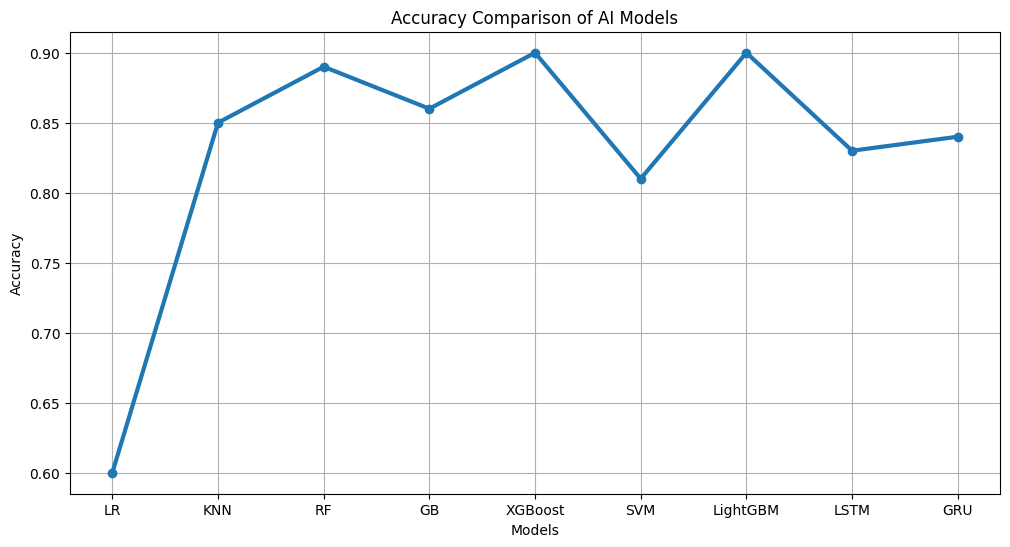

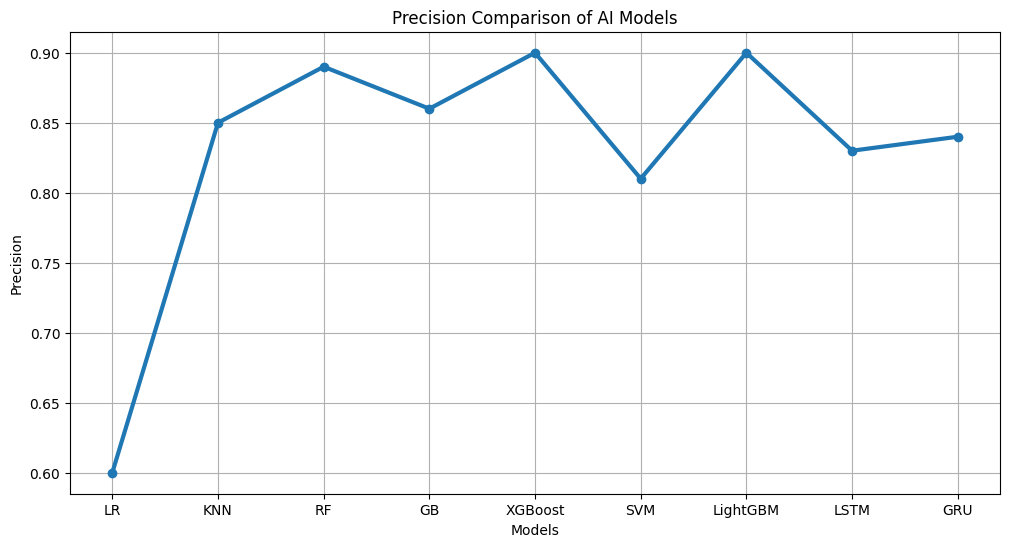

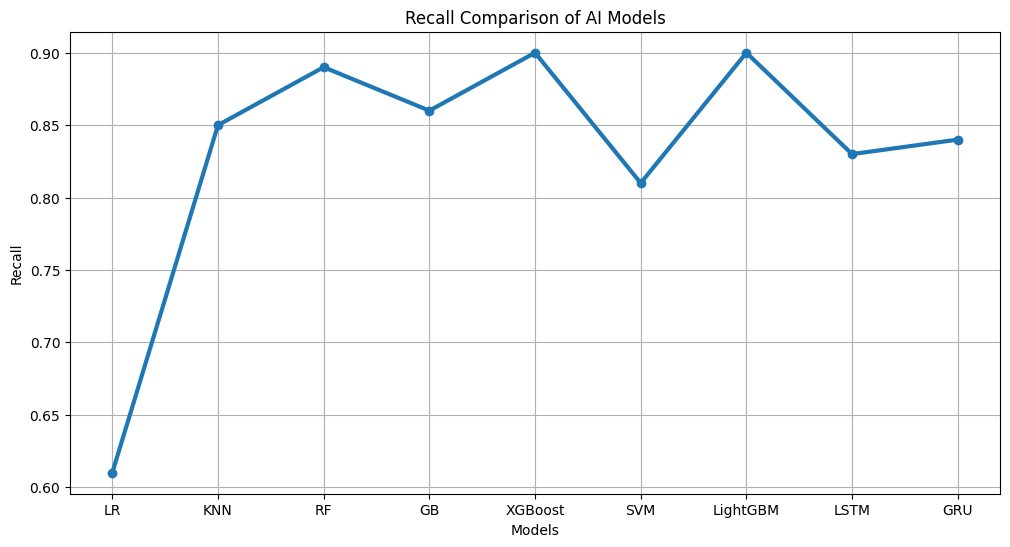

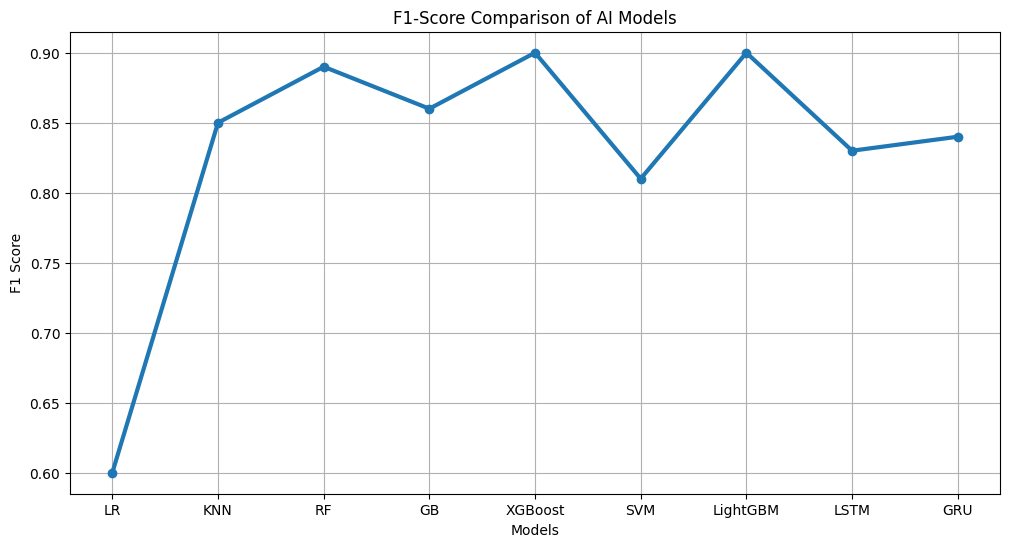

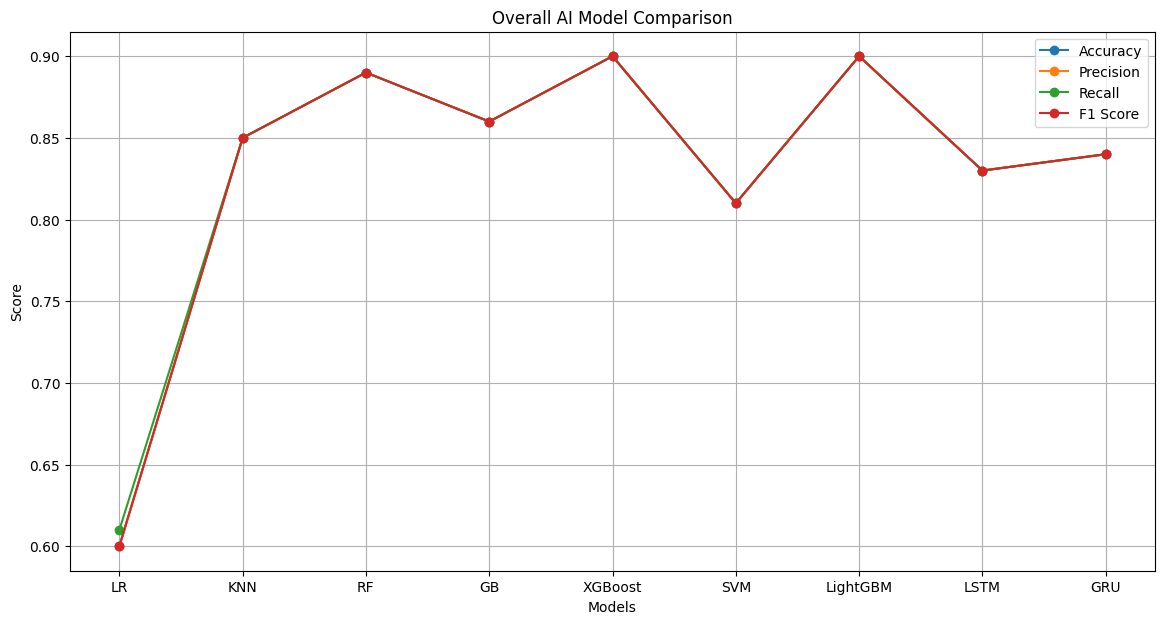

      Model  Accuracy  Precision  Recall  F1 Score
0        LR      0.60       0.60    0.61      0.60
1       KNN      0.85       0.85    0.85      0.85
2        RF      0.89       0.89    0.89      0.89
3        GB      0.86       0.86    0.86      0.86
4   XGBoost      0.90       0.90    0.90      0.90
5       SVM      0.81       0.81    0.81      0.81
6  LightGBM      0.90       0.90    0.90      0.90
7      LSTM      0.83       0.83    0.83      0.83
8       GRU      0.84       0.84    0.84      0.84


In [ ]:
# =========================================================
# FINAL AI MODEL COMPARISON GRAPHS
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# MODEL NAMES
# =========================================================

models = [
    'LR',
    'KNN',
    'RF',
    'GB',
    'XGBoost',
    'SVM',
    'LightGBM',
    'LSTM',
    'GRU'
]

# =========================================================
# ENTER YOUR RESULTS HERE
# =========================================================

accuracy = [
    0.60,
    0.85,
    0.89,
    0.86,
    0.90,
    0.81,
    0.90,
    0.83,
    0.84
]

precision = [
    0.60,
    0.85,
    0.89,
    0.86,
    0.90,
    0.81,
    0.90,
    0.83,
    0.84
]

recall = [
    0.61,
    0.85,
    0.89,
    0.86,
    0.90,
    0.81,
    0.90,
    0.83,
    0.84
]

f1_score = [
    0.60,
    0.85,
    0.89,
    0.86,
    0.90,
    0.81,
    0.90,
    0.83,
    0.84
]

# =========================================================
# ACCURACY GRAPH
# =========================================================

plt.figure(figsize=(12,6))

plt.plot(
    models,
    accuracy,
    marker='o',
    linewidth=3
)

plt.title("Accuracy Comparison of AI Models")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.grid()

plt.show()

# =========================================================
# PRECISION GRAPH
# =========================================================

plt.figure(figsize=(12,6))

plt.plot(
    models,
    precision,
    marker='o',
    linewidth=3
)

plt.title("Precision Comparison of AI Models")

plt.xlabel("Models")

plt.ylabel("Precision")

plt.grid()

plt.show()

# =========================================================
# RECALL GRAPH
# =========================================================

plt.figure(figsize=(12,6))

plt.plot(
    models,
    recall,
    marker='o',
    linewidth=3
)

plt.title("Recall Comparison of AI Models")

plt.xlabel("Models")

plt.ylabel("Recall")

plt.grid()

plt.show()

# =========================================================
# F1 SCORE GRAPH
# =========================================================

plt.figure(figsize=(12,6))

plt.plot(
    models,
    f1_score,
    marker='o',
    linewidth=3
)

plt.title("F1-Score Comparison of AI Models")

plt.xlabel("Models")

plt.ylabel("F1 Score")

plt.grid()

plt.show()

# =========================================================
# FINAL COMBINED GRAPH
# =========================================================

plt.figure(figsize=(14,7))

plt.plot(models, accuracy, marker='o', label='Accuracy')
plt.plot(models, precision, marker='o', label='Precision')
plt.plot(models, recall, marker='o', label='Recall')
plt.plot(models, f1_score, marker='o', label='F1 Score')

plt.title("Overall AI Model Comparison")

plt.xlabel("Models")

plt.ylabel("Score")

plt.legend()

plt.grid()

plt.show()

# =========================================================
# FINAL RESULT TABLE
# =========================================================

results = pd.DataFrame({

    "Model": models,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1_score
})

print(results)

In [ ]:
import pandas as pd

# Features
features = pd.read_csv(
    '/content/features.txt',
    sep=r'\s+',
    header=None
)

feature_names = features[1].tolist()

# Training Data
X_train = pd.read_csv(
    '/content/X_train.txt',
    sep=r'\s+',
    header=None
)

y_train = pd.read_csv(
    '/content/y_train.txt',
    header=None
)

# Test Data
X_test = pd.read_csv(
    '/content/X_test.txt',
    sep=r'\s+',
    header=None
)

y_test = pd.read_csv(
    '/content/y_test.txt',
    header=None
)

# Assign feature names
X_train.columns = feature_names
X_test.columns = feature_names

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (7352, 561)
X_test Shape: (2947, 561)
y_train Shape: (7352, 1)
y_test Shape: (2947, 1)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Convert labels from 1-6 to 0-5

y_train = y_train[0] - 1
y_test = y_test[0] - 1

print(sorted(y_train.unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()

y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=6,
    n_estimators=100,
    eval_metric='mlogloss',
    random_state=42
)

xgb.fit(X_train_np, y_train_np)

pred = xgb.predict(X_test_np)

print("Accuracy:", accuracy_score(y_test_np, pred))

Accuracy: 0.9379029521547336


In [ ]:
import re

# Clean feature names
clean_columns = []

for col in X_train.columns:
    col = re.sub(r'[^A-Za-z0-9_]', '_', str(col))
    clean_columns.append(col)

X_train.columns = clean_columns
X_test.columns = clean_columns

In [ ]:
print(X_train.columns[:5])

Index(['tBodyAcc_mean___X', 'tBodyAcc_mean___Y', 'tBodyAcc_mean___Z',
       'tBodyAcc_std___X', 'tBodyAcc_std___Y'],
      dtype='object')


In [ ]:
import re
import pandas as pd

# Clean feature names
new_cols = []

for i, col in enumerate(X_train.columns):
    clean = re.sub(r'[^A-Za-z0-9_]', '_', str(col))

    # add index to make unique
    clean = f"{clean}_{i}"

    new_cols.append(clean)

X_train.columns = new_cols
X_test.columns = new_cols

print("Columns cleaned successfully")

Columns cleaned successfully


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

lgbm = LGBMClassifier(
    n_estimators=100,
    random_state=42
)

lgbm.fit(X_train, y_train)

pred = lgbm.predict(X_test)

acc = accuracy_score(y_test, pred)

print("LightGBM Accuracy:", acc)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.154157 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 140170
[LightGBM] [Info] Number of data points in the train set: 7352, number of used features: 561
[LightGBM] [Info] Start training from score -1.791216
[LightGBM] [Info] Start training from score -1.924514
[LightGBM] [Info] Start training from score -2.009071
[LightGBM] [Info] Start training from score -1.743436
[LightGBM] [Info] Start training from score -1.677246
[LightGBM] [Info] Start training from score -1.653513
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

In [ ]:
from sklearn.metrics import accuracy_score

# Logistic Regression
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)
pred = lr.predict(X_test_scaled)
print("LR:", accuracy_score(y_test, pred))

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
pred = knn.predict(X_test_scaled)
print("KNN:", accuracy_score(y_test, pred))

# SVM
svm = SVC()
svm.fit(X_train_scaled, y_train)
pred = svm.predict(X_test_scaled)
print("SVM:", accuracy_score(y_test, pred))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print("RF:", accuracy_score(y_test, pred))

LR: 0.9548693586698337
KNN: 0.8802171700033933
SVM: 0.9521547336274178
RF: 0.9256871394638616


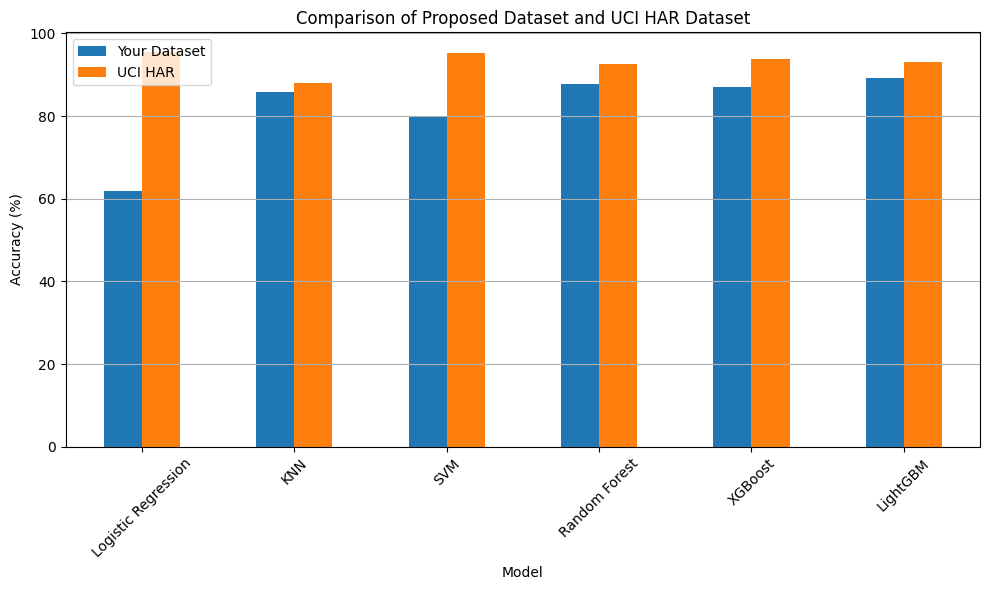

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'SVM',
        'Random Forest',
        'XGBoost',
        'LightGBM'
    ],

    'Your Dataset': [
        61.94,
        85.90,
        79.90,
        87.80,
        87.10,
        89.20
    ],

    'UCI HAR': [
        95.49,
        88.02,
        95.22,
        92.57,
        93.79,
        93.18
    ]
})

comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.ylabel('Accuracy (%)')
plt.title('Comparison of Proposed Dataset and UCI HAR Dataset')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

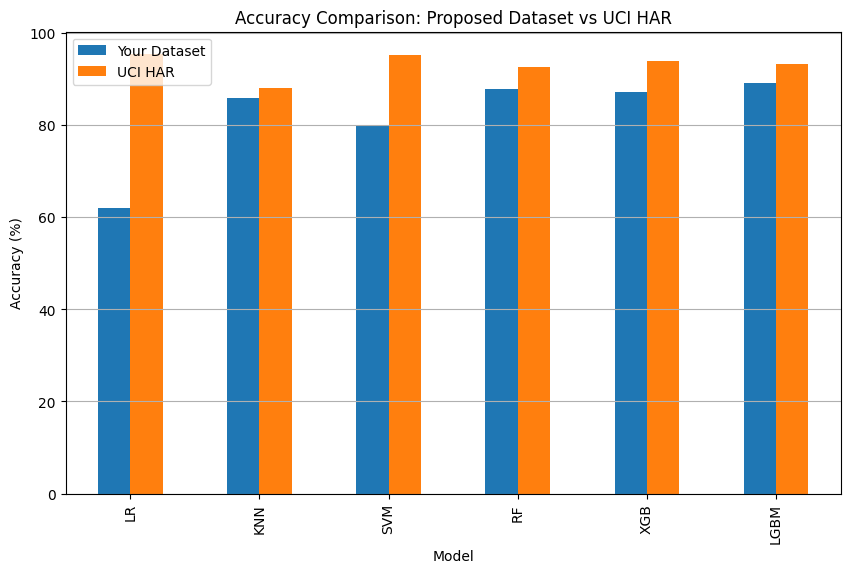

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    'Model': ['LR','KNN','SVM','RF','XGB','LGBM'],
    'Your Dataset': [61.94,85.90,79.90,87.80,87.10,89.20],
    'UCI HAR': [95.49,88.02,95.22,92.57,93.79,93.18]
})

comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison: Proposed Dataset vs UCI HAR')
plt.grid(axis='y')
plt.show()

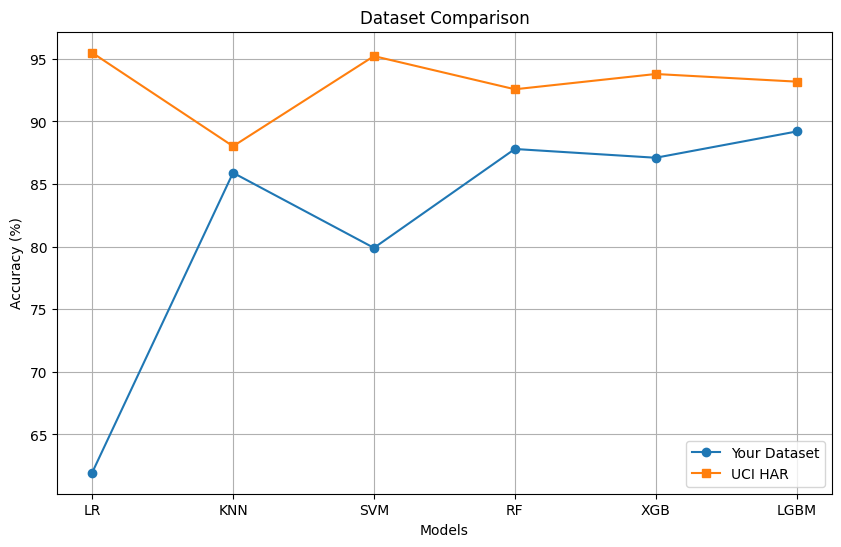

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    comparison['Model'],
    comparison['Your Dataset'],
    marker='o',
    label='Your Dataset'
)

plt.plot(
    comparison['Model'],
    comparison['UCI HAR'],
    marker='s',
    label='UCI HAR'
)

plt.title('Dataset Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.show()

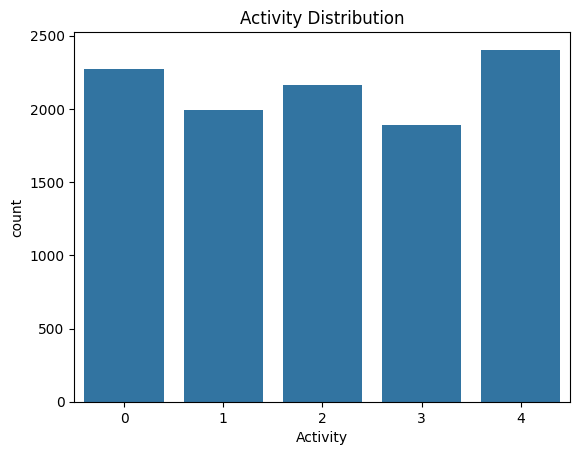

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Activity', data=df)
plt.title('Activity Distribution')
plt.show()

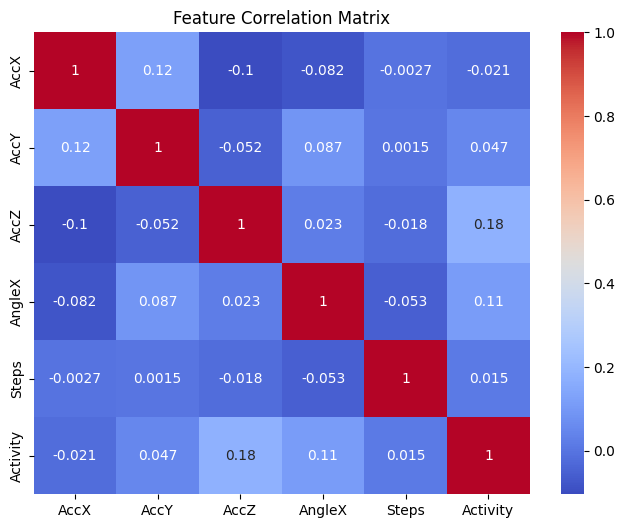

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Load dataset
df = pd.read_csv("gait_dataset.csv")

X = df.drop("Activity", axis=1)
y = df["Activity"]

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One-hot encoding
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# ANN Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(y_train_cat.shape[1], activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train_cat,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Prediction
y_pred = np.argmax(model.predict(X_test), axis=1)

acc = accuracy_score(y_test, y_pred)

print("ANN Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5608 - loss: 1.1656 - val_accuracy: 0.6911 - val_loss: 0.8688
Epoch 2/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6759 - loss: 0.8441 - val_accuracy: 0.7127 - val_loss: 0.7447
Epoch 3/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7095 - loss: 0.7574 - val_accuracy: 0.7407 - val_loss: 0.6930
Epoch 4/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7348 - loss: 0.7046 - val_accuracy: 0.7477 - val_loss: 0.6583
Epoch 5/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7494 - loss: 0.6835 - val_accuracy: 0.7774 - val_loss: 0.6278
Epoch 6/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7622 - loss: 0.6532 - val_accuracy: 0.7797 - val_loss: 0.6130
Epoch 7/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7653 - loss: 0.6352 - val_accuracy: 0.7896 - val_loss: 0.5946
Epoch 8/30
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7754 - loss: 0.6254 - val_accuracy: 0.

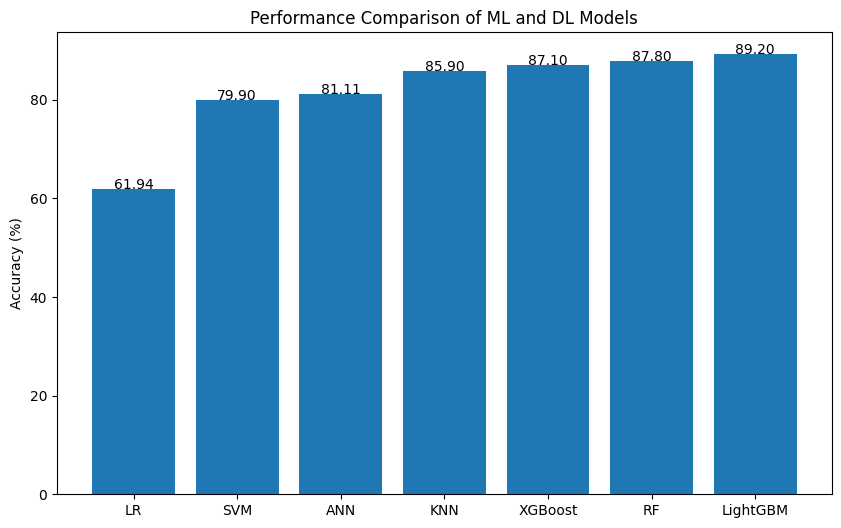

In [ ]:
import matplotlib.pyplot as plt

models = [
    'LR',
    'SVM',
    'ANN',
    'KNN',
    'XGBoost',
    'RF',
    'LightGBM'
]

accuracy = [
    61.94,
    79.90,
    81.11,
    85.90,
    87.10,
    87.80,
    89.20
]

plt.figure(figsize=(10,6))

bars = plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")
plt.title("Performance Comparison of ML and DL Models")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center'
    )

plt.show()

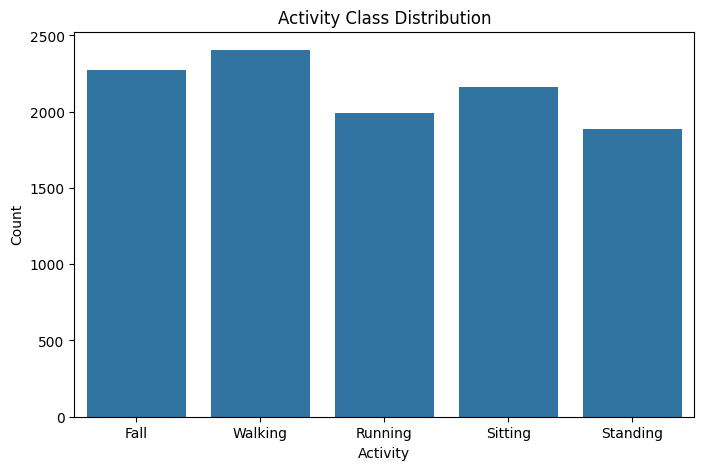

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x='Activity',
    data=df
)

plt.title('Activity Class Distribution')
plt.xlabel('Activity')
plt.ylabel('Count')

plt.show()

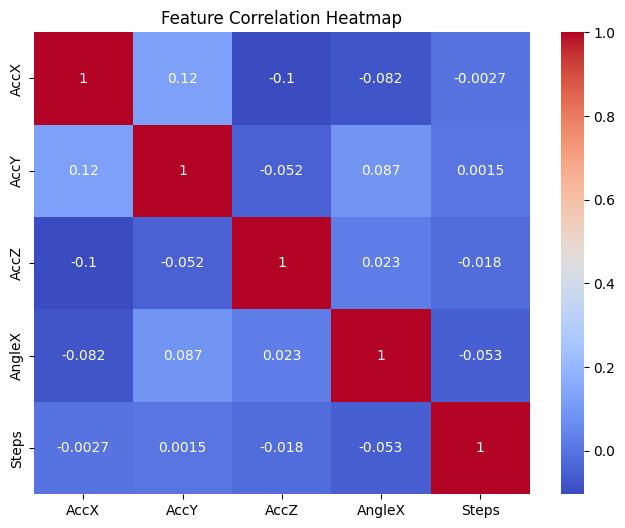

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap')

plt.show()

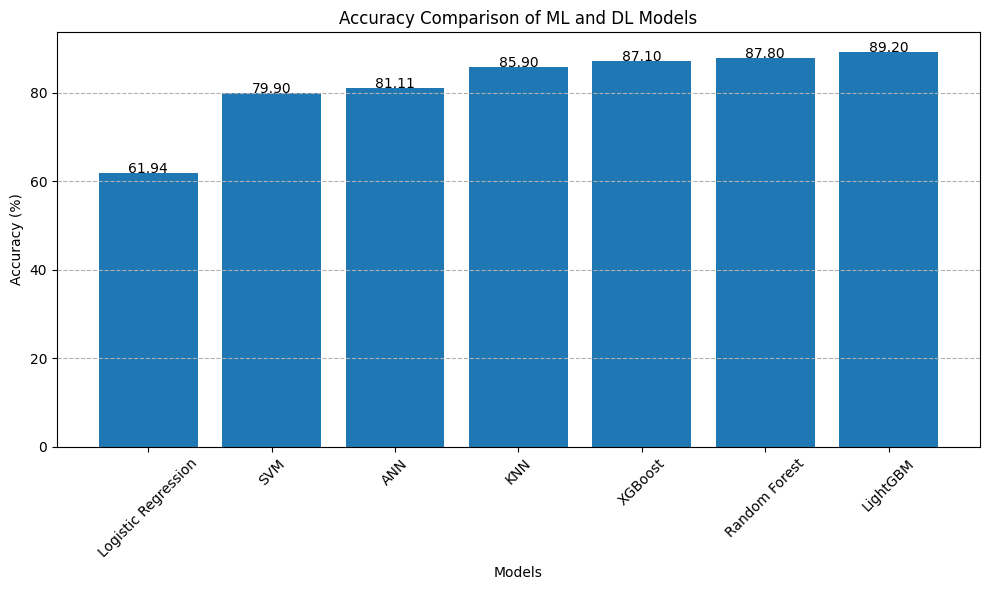

In [ ]:
import matplotlib.pyplot as plt

models = [
    'Logistic Regression',
    'SVM',
    'ANN',
    'KNN',
    'XGBoost',
    'Random Forest',
    'LightGBM'
]

accuracy = [
    61.94,
    79.90,
    81.11,
    85.90,
    87.10,
    87.80,
    89.20
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    models,
    accuracy
)

plt.title(
    'Accuracy Comparison of ML and DL Models'
)

plt.xlabel('Models')
plt.ylabel('Accuracy (%)')

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center'
    )

plt.xticks(rotation=45)

plt.grid(
    axis='y',
    linestyle='--'
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================
# Step 1: Import Required Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import ConfusionMatrixDisplay

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving gait_dataset.csv to gait_dataset (1).csv


In [ ]:
df = pd.read_csv("gait_dataset.csv")

df.head()

,AccX,AccY,AccZ,AngleX,Steps,Activity
0,-0.17,0.01,1.02,10.97,0,Fall
1,-0.16,0.15,0.89,4.34,0,Fall
2,-0.91,0.67,1.11,9.11,1,Fall
3,-0.13,-0.06,1.02,18.10,1,Fall
4,-0.03,0.06,0.96,15.62,1,Fall


In [ ]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(10720, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10720 entries, 0 to 10719
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AccX      10720 non-null  float64
 1   AccY      10720 non-null  float64
 2   AccZ      10720 non-null  float64
 3   AngleX    10720 non-null  float64
 4   Steps     10720 non-null  int64  
 5   Activity  10720 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 502.6+ KB
None
               AccX          AccY          AccZ        AngleX         Steps
count  10720.000000  10720.000000  10720.000000  10720.000000  10720.000000
mean       0.030468     -0.049069      0.976384     -2.449393     50.364459
std        0.456108      0.466728      0.489076     59.210612     59.445435
min       -2.060000     -2.650000     -1.810000   -179.240000      0.000000
25%       -0.090000     -0.180000      0.820000    -36.050000      2.000000
50%        0.010000      0.000000      1.000

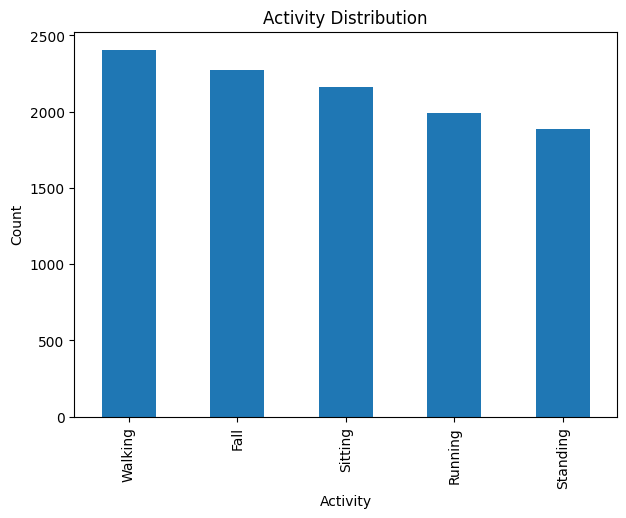

In [ ]:
plt.figure(figsize=(7,5))

df['Activity'].value_counts().plot(kind='bar')

plt.title("Activity Distribution")

plt.xlabel("Activity")

plt.ylabel("Count")

plt.show()

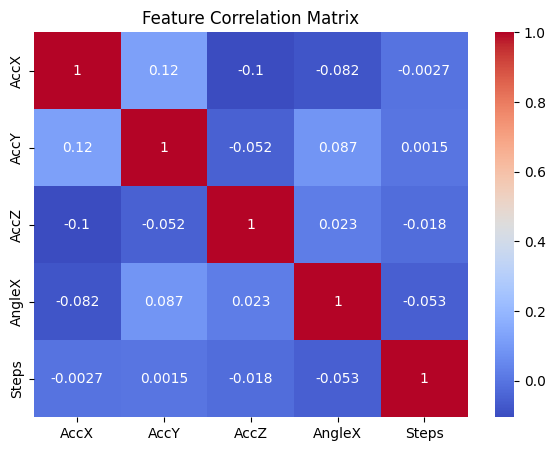

In [ ]:
import seaborn as sns

plt.figure(figsize=(7,5))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()

In [ ]:
encoder = LabelEncoder()

df["Activity"] = encoder.fit_transform(df["Activity"])

df.head()

,AccX,AccY,AccZ,AngleX,Steps,Activity
0,-0.17,0.01,1.02,10.97,0,0
1,-0.16,0.15,0.89,4.34,0,0
2,-0.91,0.67,1.11,9.11,1,0
3,-0.13,-0.06,1.02,18.10,1,0
4,-0.03,0.06,0.96,15.62,1,0


In [ ]:
X = df[['AccX',
        'AccY',
        'AccZ',
        'AngleX',
        'Steps']]

y = df['Activity']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(

X,

y,

test_size=0.2,

random_state=42)

print(X_train.shape)

print(X_test.shape)

(8576, 5)
(2144, 5)


In [ ]:
# ============================================
# Logistic Regression
# ============================================

LR = LogisticRegression(max_iter=1000)

LR.fit(X_train, y_train)

y_pred_lr = LR.predict(X_test)

print("Logistic Regression Accuracy :",
      accuracy_score(y_test, y_pred_lr))

print("Precision :",
      precision_score(y_test, y_pred_lr, average='weighted'))

print("Recall :",
      recall_score(y_test, y_pred_lr, average='weighted'))

print("F1 Score :",
      f1_score(y_test, y_pred_lr, average='weighted'))

Logistic Regression Accuracy : 0.6100746268656716
Precision : 0.6024341945724221
Recall : 0.6100746268656716
F1 Score : 0.599070572354361


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# ============================================
# KNN
# ============================================

KNN = KNeighborsClassifier(n_neighbors=5)

KNN.fit(X_train, y_train)

y_pred_knn = KNN.predict(X_test)

print("KNN Accuracy :",
      accuracy_score(y_test, y_pred_knn))

print("Precision :",
      precision_score(y_test, y_pred_knn, average='weighted'))

print("Recall :",
      recall_score(y_test, y_pred_knn, average='weighted'))

print("F1 Score :",
      f1_score(y_test, y_pred_knn, average='weighted'))

KNN Accuracy : 0.7915111940298507
Precision : 0.7936410303694493
Recall : 0.7915111940298507
F1 Score : 0.7889512525595114


In [ ]:
# ============================================
# SVM
# ============================================

SVM = SVC(probability=True)

SVM.fit(X_train, y_train)

y_pred_svm = SVM.predict(X_test)

print("SVM Accuracy :",
      accuracy_score(y_test, y_pred_svm))

print("Precision :",
      precision_score(y_test, y_pred_svm, average='weighted'))

print("Recall :",
      recall_score(y_test, y_pred_svm, average='weighted'))

print("F1 Score :",
      f1_score(y_test, y_pred_svm, average='weighted'))

SVM Accuracy : 0.6259328358208955
Precision : 0.6300449846379615
Recall : 0.6259328358208955
F1 Score : 0.6141906406546969


In [ ]:
# ============================================
# Random Forest
# ============================================

RF = RandomForestClassifier(
    n_estimators=100,
    random_state=42)

RF.fit(X_train, y_train)

y_pred_rf = RF.predict(X_test)

print("Random Forest Accuracy :",
      accuracy_score(y_test, y_pred_rf))

print("Precision :",
      precision_score(y_test, y_pred_rf, average='weighted'))

print("Recall :",
      recall_score(y_test, y_pred_rf, average='weighted'))

print("F1 Score :",
      f1_score(y_test, y_pred_rf, average='weighted'))

Random Forest Accuracy : 0.8833955223880597
Precision : 0.8839152425092548
Recall : 0.8833955223880597
F1 Score : 0.8830361744508525


In [ ]:
# ============================================
# XGBoost
# ============================================

XGB = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42)

XGB.fit(X_train, y_train)

y_pred_xgb = XGB.predict(X_test)

print("XGBoost Accuracy :",
      accuracy_score(y_test, y_pred_xgb))

print("Precision :",
      precision_score(y_test, y_pred_xgb, average='weighted'))

print("Recall :",
      recall_score(y_test, y_pred_xgb, average='weighted'))

print("F1 Score :",
      f1_score(y_test, y_pred_xgb, average='weighted'))

XGBoost Accuracy : 0.9015858208955224
Precision : 0.9016504137040257
Recall : 0.9015858208955224
F1 Score : 0.9011911346301763


In [ ]:
# ============================================
# LightGBM
# ============================================

LGB = LGBMClassifier(
    random_state=42)

LGB.fit(X_train, y_train)

y_pred_lgb = LGB.predict(X_test)

print("LightGBM Accuracy :",
      accuracy_score(y_test, y_pred_lgb))

print("Precision :",
      precision_score(y_test, y_pred_lgb, average='weighted'))

print("Recall :",
      recall_score(y_test, y_pred_lgb, average='weighted'))

print("F1 Score :",
      f1_score(y_test, y_pred_lgb, average='weighted'))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002812 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1234
[LightGBM] [Info] Number of data points in the train set: 8576, number of used features: 5
[LightGBM] [Info] Start training from score -1.551781
[LightGBM] [Info] Start training from score -1.685863
[LightGBM] [Info] Start training from score -1.589923
[LightGBM] [Info] Start training from score -1.737520
[LightGBM] [Info] Start training from score -1.500818
LightGBM Accuracy : 0.9043843283582089
Precision : 0.9051986671363257
Recall : 0.9043843283582089
F1 Score : 0.9039471429739986


In [ ]:
# ============================================
# ANN
# ============================================

ANN = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    random_state=42)

ANN.fit(X_train, y_train)

y_pred_ann = ANN.predict(X_test)

print("ANN Accuracy :",
      accuracy_score(y_test, y_pred_ann))

print("Precision :",
      precision_score(y_test, y_pred_ann, average='weighted'))

print("Recall :",
      recall_score(y_test, y_pred_ann, average='weighted'))

print("F1 Score :",
      f1_score(y_test, y_pred_ann, average='weighted'))

ANN Accuracy : 0.792910447761194
Precision : 0.791188584818615
Recall : 0.792910447761194
F1 Score : 0.7883408126275662


In [ ]:
# ============================================
# Step 17: Performance Comparison Table
# ============================================

results = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'SVM',
        'ANN',
        'KNN',
        'Random Forest',
        'XGBoost',
        'LightGBM'
    ],

    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_svm),
        accuracy_score(y_test,y_pred_ann),
        accuracy_score(y_test,y_pred_knn),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_xgb),
        accuracy_score(y_test,y_pred_lgb)
    ],

    'Precision':[
        precision_score(y_test,y_pred_lr,average='weighted'),
        precision_score(y_test,y_pred_svm,average='weighted'),
        precision_score(y_test,y_pred_ann,average='weighted'),
        precision_score(y_test,y_pred_knn,average='weighted'),
        precision_score(y_test,y_pred_rf,average='weighted'),
        precision_score(y_test,y_pred_xgb,average='weighted'),
        precision_score(y_test,y_pred_lgb,average='weighted')
    ],

    'Recall':[
        recall_score(y_test,y_pred_lr,average='weighted'),
        recall_score(y_test,y_pred_svm,average='weighted'),
        recall_score(y_test,y_pred_ann,average='weighted'),
        recall_score(y_test,y_pred_knn,average='weighted'),
        recall_score(y_test,y_pred_rf,average='weighted'),
        recall_score(y_test,y_pred_xgb,average='weighted'),
        recall_score(y_test,y_pred_lgb,average='weighted')
    ],

    'F1 Score':[
        f1_score(y_test,y_pred_lr,average='weighted'),
        f1_score(y_test,y_pred_svm,average='weighted'),
        f1_score(y_test,y_pred_ann,average='weighted'),
        f1_score(y_test,y_pred_knn,average='weighted'),
        f1_score(y_test,y_pred_rf,average='weighted'),
        f1_score(y_test,y_pred_xgb,average='weighted'),
        f1_score(y_test,y_pred_lgb,average='weighted')
    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.610075,0.602434,0.610075,0.599071
1,SVM,0.625933,0.630045,0.625933,0.614191
2,ANN,0.792910,0.791189,0.792910,0.788341
3,KNN,0.791511,0.793641,0.791511,0.788951
4,Random Forest,0.883396,0.883915,0.883396,0.883036
5,XGBoost,0.901586,0.901650,0.901586,0.901191
6,LightGBM,0.904384,0.905199,0.904384,0.903947


In [ ]:
results_percent = results.copy()

results_percent.iloc[:,1:] = results_percent.iloc[:,1:]*100

results_percent = results_percent.round(2)

results_percent

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,61.01,60.24,61.01,59.91
1,SVM,62.59,63.00,62.59,61.42
2,ANN,79.29,79.12,79.29,78.83
3,KNN,79.15,79.36,79.15,78.90
4,Random Forest,88.34,88.39,88.34,88.30
5,XGBoost,90.16,90.17,90.16,90.12
6,LightGBM,90.44,90.52,90.44,90.39


In [ ]:
results_percent.to_csv("Performance_Table.csv",
                       index=False)

print("Saved Successfully")

Saved Successfully


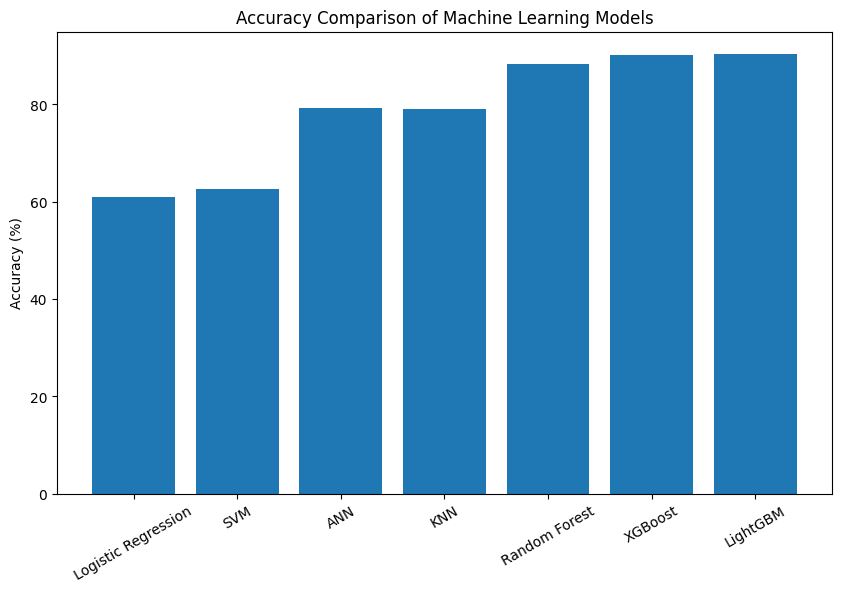

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(results_percent['Model'],
        results_percent['Accuracy'])

plt.xticks(rotation=30)

plt.ylabel("Accuracy (%)")

plt.title("Accuracy Comparison of Machine Learning Models")

plt.show()

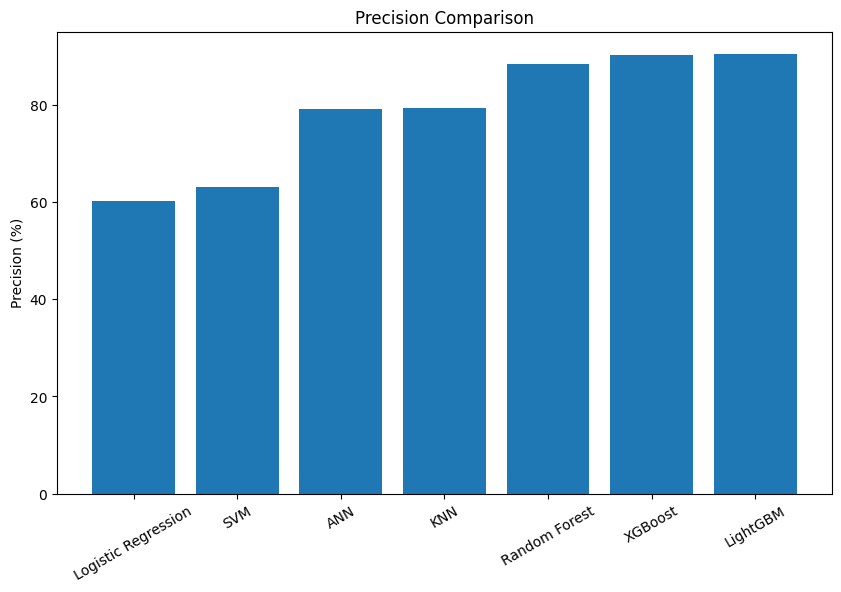

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(results_percent['Model'],
        results_percent['Precision'])

plt.xticks(rotation=30)

plt.ylabel("Precision (%)")

plt.title("Precision Comparison")

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
import pandas as pd

# Create Performance Table
performance = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Support Vector Machine",
        "Artificial Neural Network",
        "K-Nearest Neighbor",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],

    "Accuracy (%)":[

        accuracy_score(y_test,y_pred_lr)*100,

        accuracy_score(y_test,y_pred_svm)*100,

        accuracy_score(y_test,y_pred_ann)*100,

        accuracy_score(y_test,y_pred_knn)*100,

        accuracy_score(y_test,y_pred_rf)*100,

        accuracy_score(y_test,y_pred_xgb)*100,

        accuracy_score(y_test,y_pred_lgb)*100
    ],

    "Precision (%)":[

        precision_score(y_test,y_pred_lr,average='weighted')*100,

        precision_score(y_test,y_pred_svm,average='weighted')*100,

        precision_score(y_test,y_pred_ann,average='weighted')*100,

        precision_score(y_test,y_pred_knn,average='weighted')*100,

        precision_score(y_test,y_pred_rf,average='weighted')*100,

        precision_score(y_test,y_pred_xgb,average='weighted')*100,

        precision_score(y_test,y_pred_lgb,average='weighted')*100
    ],

    "Recall (%)":[

        recall_score(y_test,y_pred_lr,average='weighted')*100,

        recall_score(y_test,y_pred_svm,average='weighted')*100,

        recall_score(y_test,y_pred_ann,average='weighted')*100,

        recall_score(y_test,y_pred_knn,average='weighted')*100,

        recall_score(y_test,y_pred_rf,average='weighted')*100,

        recall_score(y_test,y_pred_xgb,average='weighted')*100,

        recall_score(y_test,y_pred_lgb,average='weighted')*100
    ],

    "F1-Score (%)":[

        f1_score(y_test,y_pred_lr,average='weighted')*100,

        f1_score(y_test,y_pred_svm,average='weighted')*100,

        f1_score(y_test,y_pred_ann,average='weighted')*100,

        f1_score(y_test,y_pred_knn,average='weighted')*100,

        f1_score(y_test,y_pred_rf,average='weighted')*100,

        f1_score(y_test,y_pred_xgb,average='weighted')*100,

        f1_score(y_test,y_pred_lgb,average='weighted')*100
    ]

})

performance = performance.round(2)

performance

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Logistic Regression,61.01,60.24,61.01,59.91
1,Support Vector Machine,62.59,63.00,62.59,61.42
2,Artificial Neural Network,79.29,79.12,79.29,78.83
3,K-Nearest Neighbor,79.15,79.36,79.15,78.90
4,Random Forest,88.34,88.39,88.34,88.30
5,XGBoost,90.16,90.17,90.16,90.12
6,LightGBM,90.44,90.52,90.44,90.39


In [ ]:
performance.to_csv("Performance_Comparison_Table.csv",index=False)

print("Table Saved Successfully")

Table Saved Successfully
